# 005_Cvitiai로부터 StableDiffusion 모델 다운로드 및 추론 실습


## 패키지 설치하기


In [1]:
#Diffusion Models을 쉽게 사용하고 훈련할 수 있도록 도와주는 HuggingFace Library
!pip install diffusers

## 패키지

In [3]:
import torch
import os
import requests

from diffusers import StableDiffusionImg2ImgPipeline
from diffusers.utils import make_image_grid
from PIL import Image
from tqdm import tqdm

##civitai URL로부터 모델 ID 추출

In [14]:
#url = "https://civitai.com/models/134237/disney-and-pixar-animal"
url = "https://civitai.com/models/65203/disney-pixar-cartoon-type-a"
model_id = url.replace("https://civitai.com/models/", "").split("/")[0]
print(model_id)

65203


##civitai REST API 호출

In [15]:
response = requests.get(f"https://civitai.com/api/v1/models/{model_id}")
response.json()

{'id': 65203,
 'name': 'Disney Pixar Cartoon Type A',
 'description': '<p>There\'s no good pixar disney looking cartoon model yet so i decided to make one. This is a merge of <a target="_blank" rel="ugc" href="https://civitai.com/models/15773/pixar-style-model">Pixar Style Model</a> with my own Loras to create a generic 3d looking western cartoon. In the examples I Use hires. fix, upscale latent, denoising 0.5, hires steps 20, upscale by 2 . Clip skip 2 . I will upload more variants of this in the future</p><p></p><p>You need to use VAE or the color become pale and gray</p><p></p><p><span style="color:rgb(193, 194, 197)">if you like the models, please consider supporting me on, i will continue to upload more cool stuffs in the future</span></p><p><br /><a target="_blank" rel="ugc" href="https://www.patreon.com/PromptSharingSamaritan">https://www.patreon.com/PromptSharingSamaritan</a></p><p><a target="_blank" rel="ugc" href="http://patreon.com/PromptSharingSamaritan￼"><br /></a><a targe

##모델 다운로드

In [ ]:
download_url = response.json()["modelVersions"][0]["downloadUrl"]
filename = response.json()["modelVersions"][0]["files"][0]["name"]
print("download_url:", download_url)
print("filename:", filename)


def download_from_url(url: str, file_path: str, chunk_size=1024):
    resp = requests.get(url, stream=True)
    total = int(resp.headers.get('content-length', 0))
    with open(file_path, 'wb') as file, tqdm(
        desc=file_path,
        total=total,
        unit='iB',
        unit_scale=True,
        unit_divisor=1024,
    ) as bar:
        for data in resp.iter_content(chunk_size=chunk_size):
            size = file.write(data)
            bar.update(size)


file_path = f"models/{filename}"
os.makedirs("models", exist_ok=True)
print(f"[INFO] Download start!")
download_from_url(download_url, file_path)
print(f"\n[INFO] File downloaded: {file_path}")

##모델 로드 및 파이프라인 생성하기

In [ ]:
pipeline = StableDiffusionImg2ImgPipeline.from_single_file(
        "models/disneyPixarCartoon_v10.safetensors",
        torch_dtype=torch.float16,
        use_safetensors=True,
).to("cuda")

## 추론하기

In [ ]:
input_image = Image.open("kitty.png")

prompt = (
    "kitty in the city, cartoon style, drawing, detailed"
)
negative_prompt = "ugly, blurry, bad anatomy, bad art, wierd colors"

output_images = pipeline(
    image=input_image,
    prompt=prompt,
    negative_prompt=negative_prompt,
    num_images_per_prompt=4,
    num_inference_steps=30,
    strength=0.7,
).images

##결과 확인하기

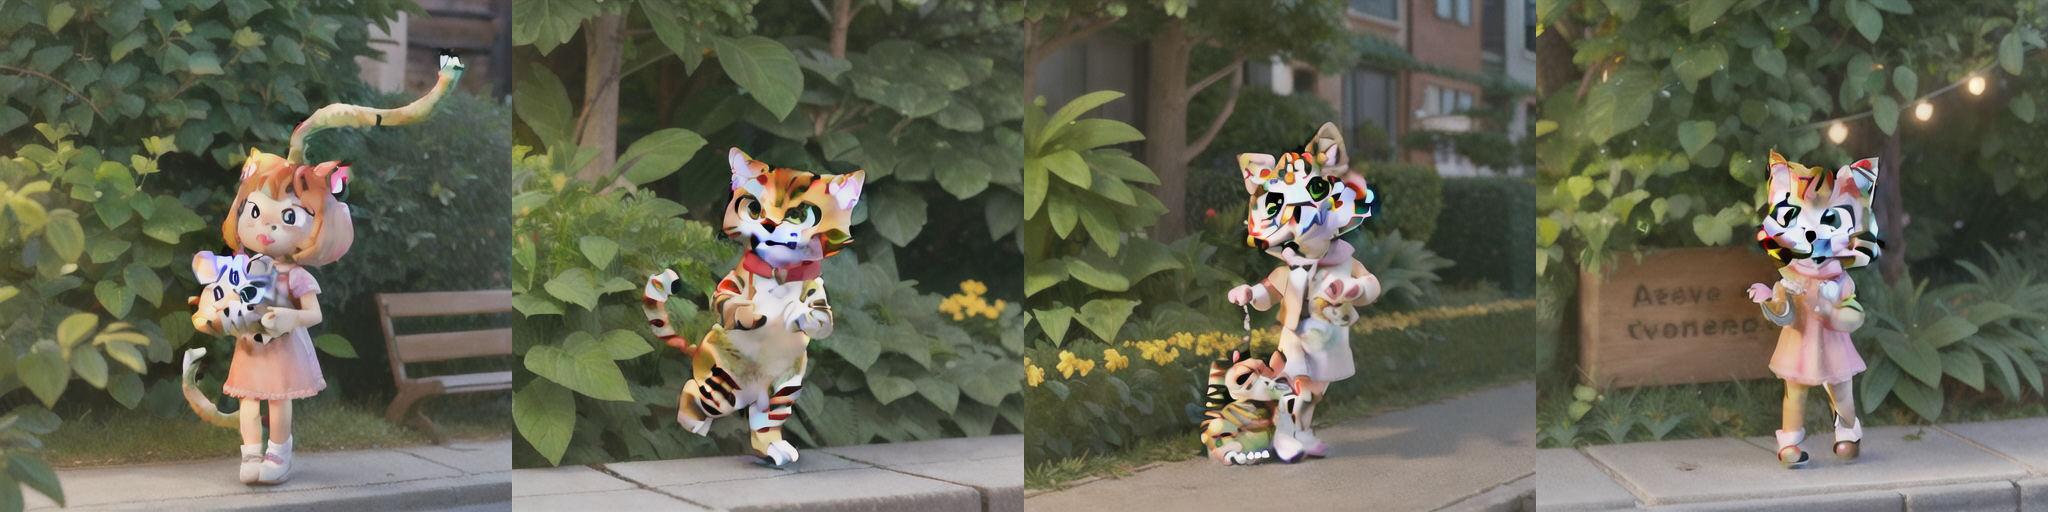

In [32]:
make_image_grid(output_images, rows=1, cols=4)